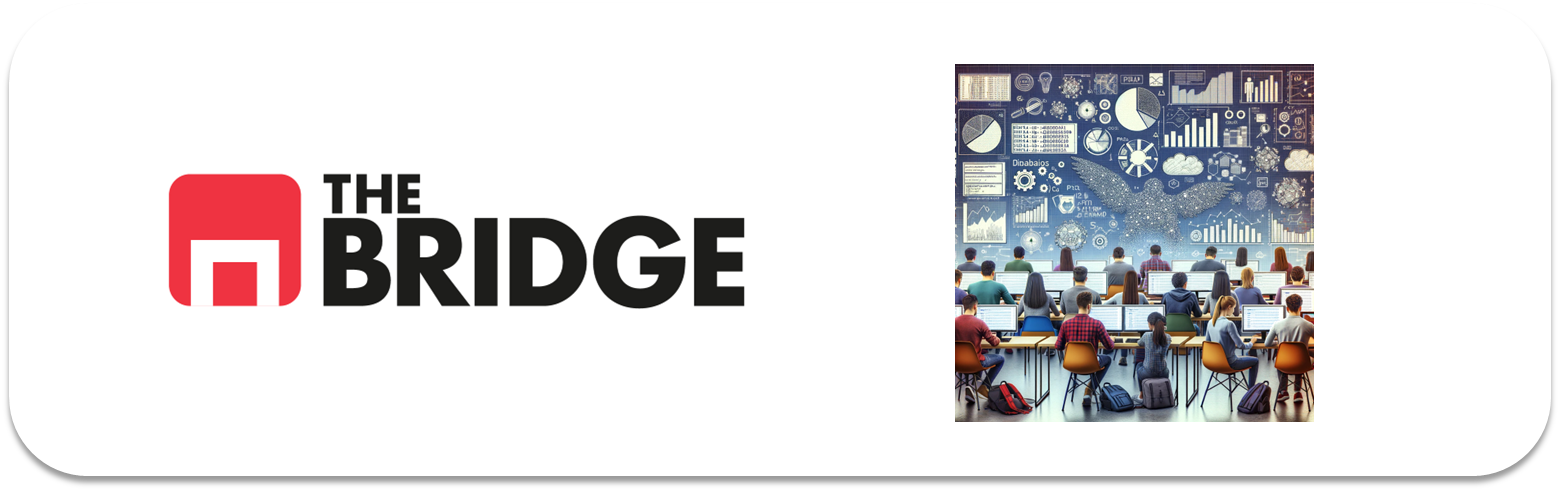

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score,\
                            roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, \
                            ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



## 1. Cargar los datos

In [2]:
df_titanic = sns.load_dataset('titanic')

## 2. Descartar los datos que no se utilizan

In [3]:
df_titanic.drop(columns=["alive", "parch", "fare", "class", "who", "adult_male", "embark_town", "sibsp"], inplace=True)

## 3. Variable Target

In [4]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   embarked  889 non-null    object  
 5   deck      203 non-null    category
 6   alone     891 non-null    bool    
dtypes: bool(1), category(1), float64(1), int64(2), object(2)
memory usage: 37.0+ KB


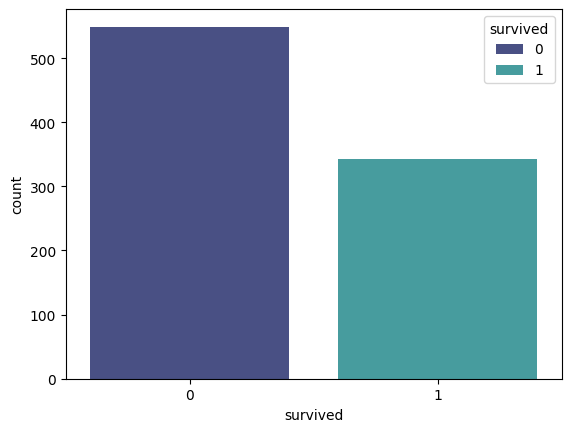

In [5]:
sns.countplot(df_titanic, x="survived", hue="survived", palette="mako");

La proporción de supervivientes y fallecidos está ligeramente sesgada hacia los fallecidos, de manera que se tendrán menos datos de los supervivientes. Esto de debe tener en cuenta al analizar la precisión y exactitud del modelo.

## 4. Split de train y test y 5. parejas

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df_titanic.drop(columns="survived"), df_titanic.survived, test_size = 0.20, random_state=51) 

In [7]:
print(X_train.pclass.value_counts(True), y_train.value_counts(True), end="\n"*2)
print(X_test.pclass.value_counts(True), y_test.value_counts(True))

pclass
3    0.55618
1    0.25000
2    0.19382
Name: proportion, dtype: float64 survived
0    0.619382
1    0.380618
Name: proportion, dtype: float64

pclass
3    0.530726
2    0.256983
1    0.212291
Name: proportion, dtype: float64 survived
0    0.603352
1    0.396648
Name: proportion, dtype: float64


La distribución entre train y test parece más o menos similar.

## 6. Imputación de nulos y 7. mini EDA

In [8]:
train_set = pd.concat([y_train, X_train], axis = 1)

In [9]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 770 to 57
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  712 non-null    int64   
 1   pclass    712 non-null    int64   
 2   sex       712 non-null    object  
 3   age       568 non-null    float64 
 4   embarked  710 non-null    object  
 5   deck      163 non-null    category
 6   alone     712 non-null    bool    
dtypes: bool(1), category(1), float64(1), int64(2), object(2)
memory usage: 35.1+ KB


Hay nulos en age y deck.

In [10]:
train_set.describe()

,survived,pclass,age
count,712.000000,712.000000,568.000000
mean,0.380618,2.306180,29.517324
std,0.485880,0.844651,14.558118
min,0.000000,1.000000,0.420000
25%,0.000000,1.750000,20.000000
50%,0.000000,3.000000,28.000000
75%,1.000000,3.000000,38.250000
max,1.000000,3.000000,71.000000


### Variables:
**Variable target**:
- alive

**Features**:
- pclass
- sex
- age
- sibsp
- embarked
- deck

In [11]:
from funciones import diagramas_barras, boxplot_histograma, histograma_por_categorias, comparar_cualitativas

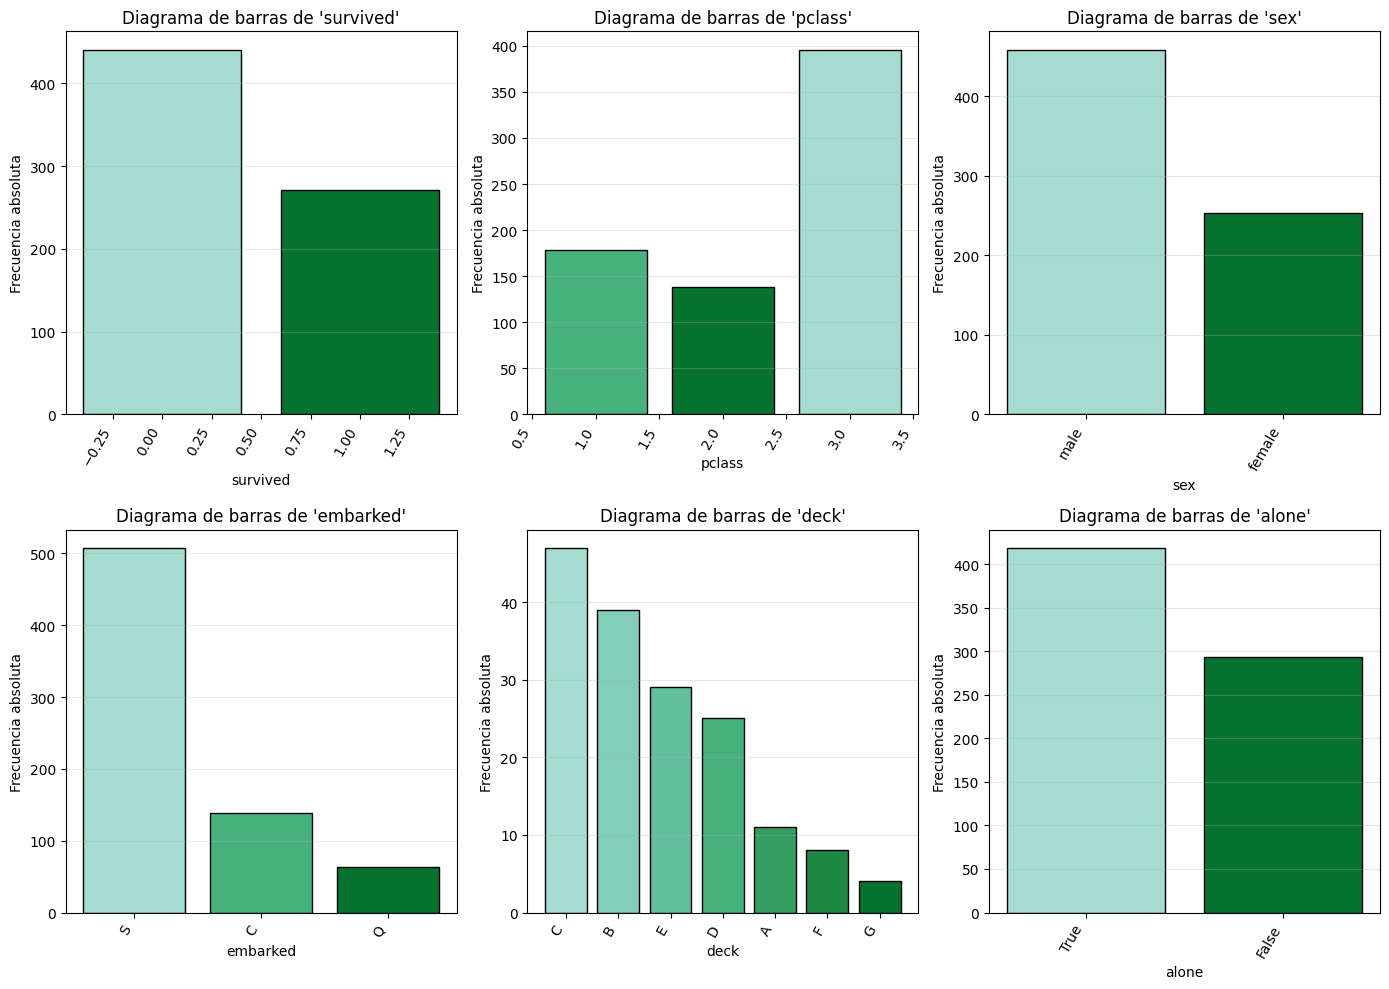

In [12]:
diagramas_barras(train_set, ["survived", "pclass", "sex", "embarked", "deck", "alone"],)

Reemplazamos los nulos con la moda, aunque se carga bastante la distribución.

In [13]:
moda_deck = X_train.deck.mode()[0]
X_train.loc[X_train.deck.isna(), "deck"] = moda_deck
X_test.loc[X_test.deck.isna(), "deck"] = moda_deck

In [14]:
moda_embarked = X_train.embarked.mode()[0]
X_train.loc[X_train.embarked.isna(), "embarked"] = moda_embarked
X_test.loc[X_test.embarked.isna(), "embarked"] = moda_embarked

In [15]:
train_set = pd.concat([y_train, X_train], axis = 1)

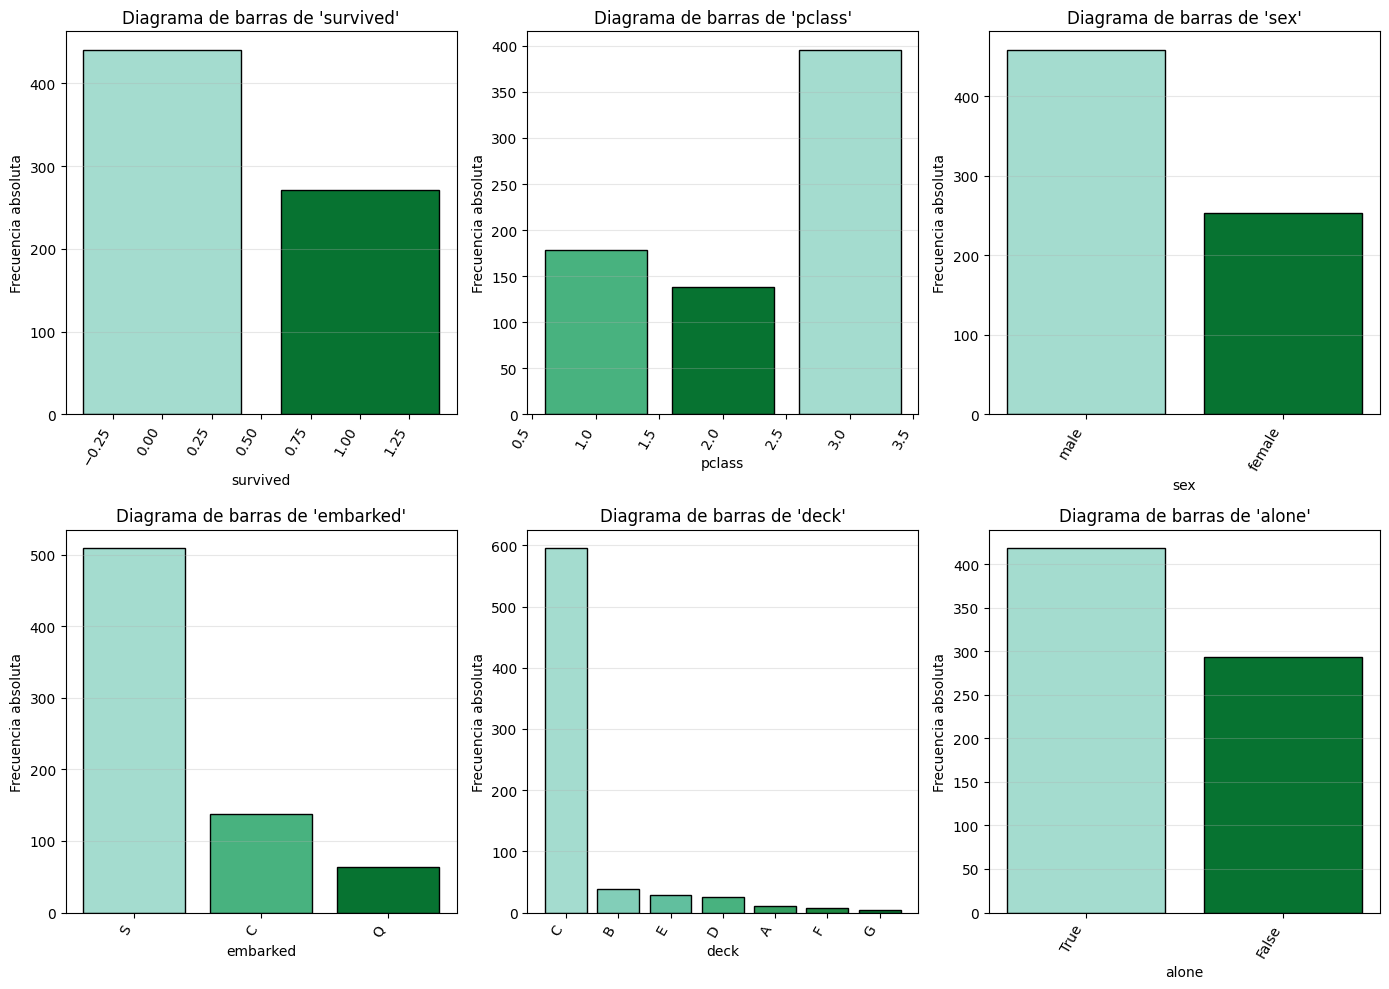

In [16]:
diagramas_barras(train_set, ["survived", "pclass", "sex", "embarked", "deck", "alone"])

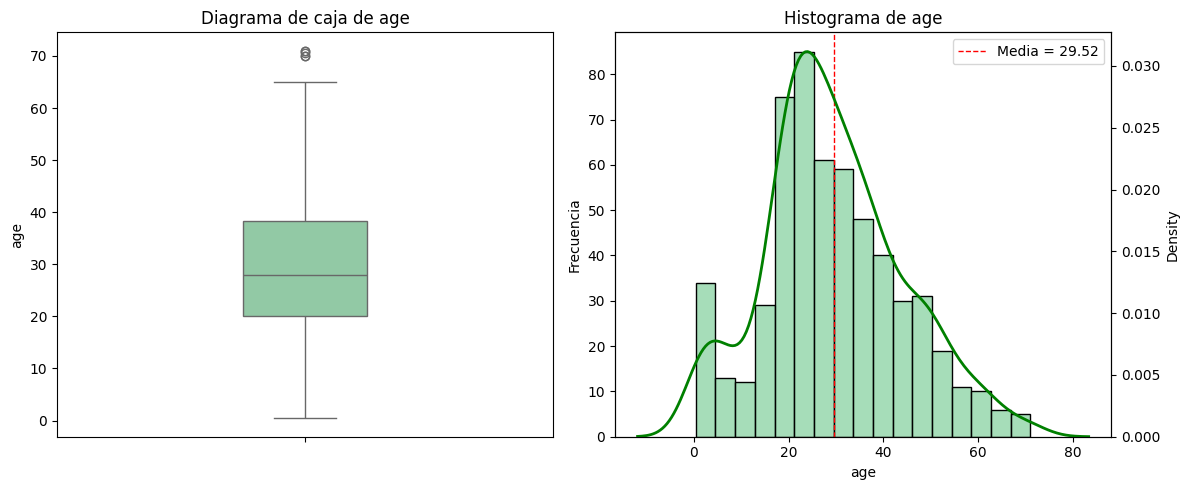

In [17]:
boxplot_histograma(train_set, "age")

Lo mismo para age:

In [18]:
media_age = X_train.age.mean()
X_train.loc[X_train.age.isna(), "age"] = media_age
X_test.loc[X_test.age.isna(), "age"] = media_age

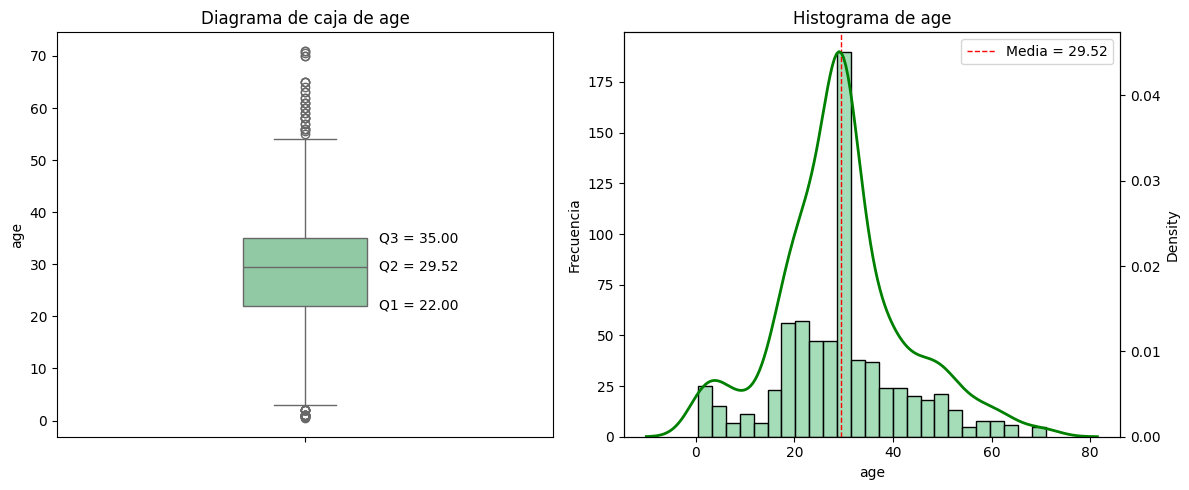

In [19]:
train_set = pd.concat([y_train, X_train], axis = 1)
boxplot_histograma(X_train, "age");

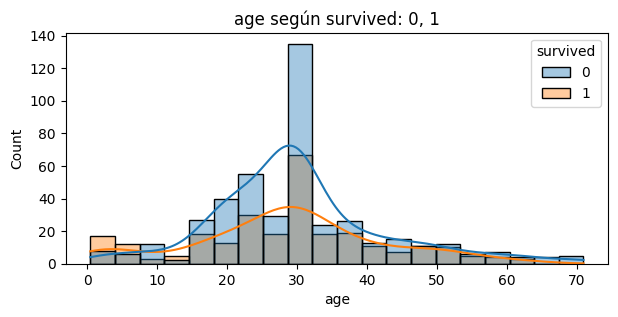

In [20]:
histograma_por_categorias(train_set, "age", "survived")

In [21]:
from scipy import stats
clases = [clase for clase in train_set.survived.unique()]
grupos = [train_set.loc[train_set.survived == clase]["age"] for clase in clases]
print("ANOVA para las poblaciones de age según survived:")
print([round(float(i), 4) for i in stats.f_oneway(*grupos)])

ANOVA para las poblaciones de age según survived:
[2.2351, 0.1354]


No existe suficiente evidencia estadística para afirmar que existe una diferencia significativa entre las medias de las poblaciones de edad según su supervivencia al incidente del titanic. Sin embargo, esta variable puede tener interacciones con otras variables, por lo que se va a mantener en el análisis.

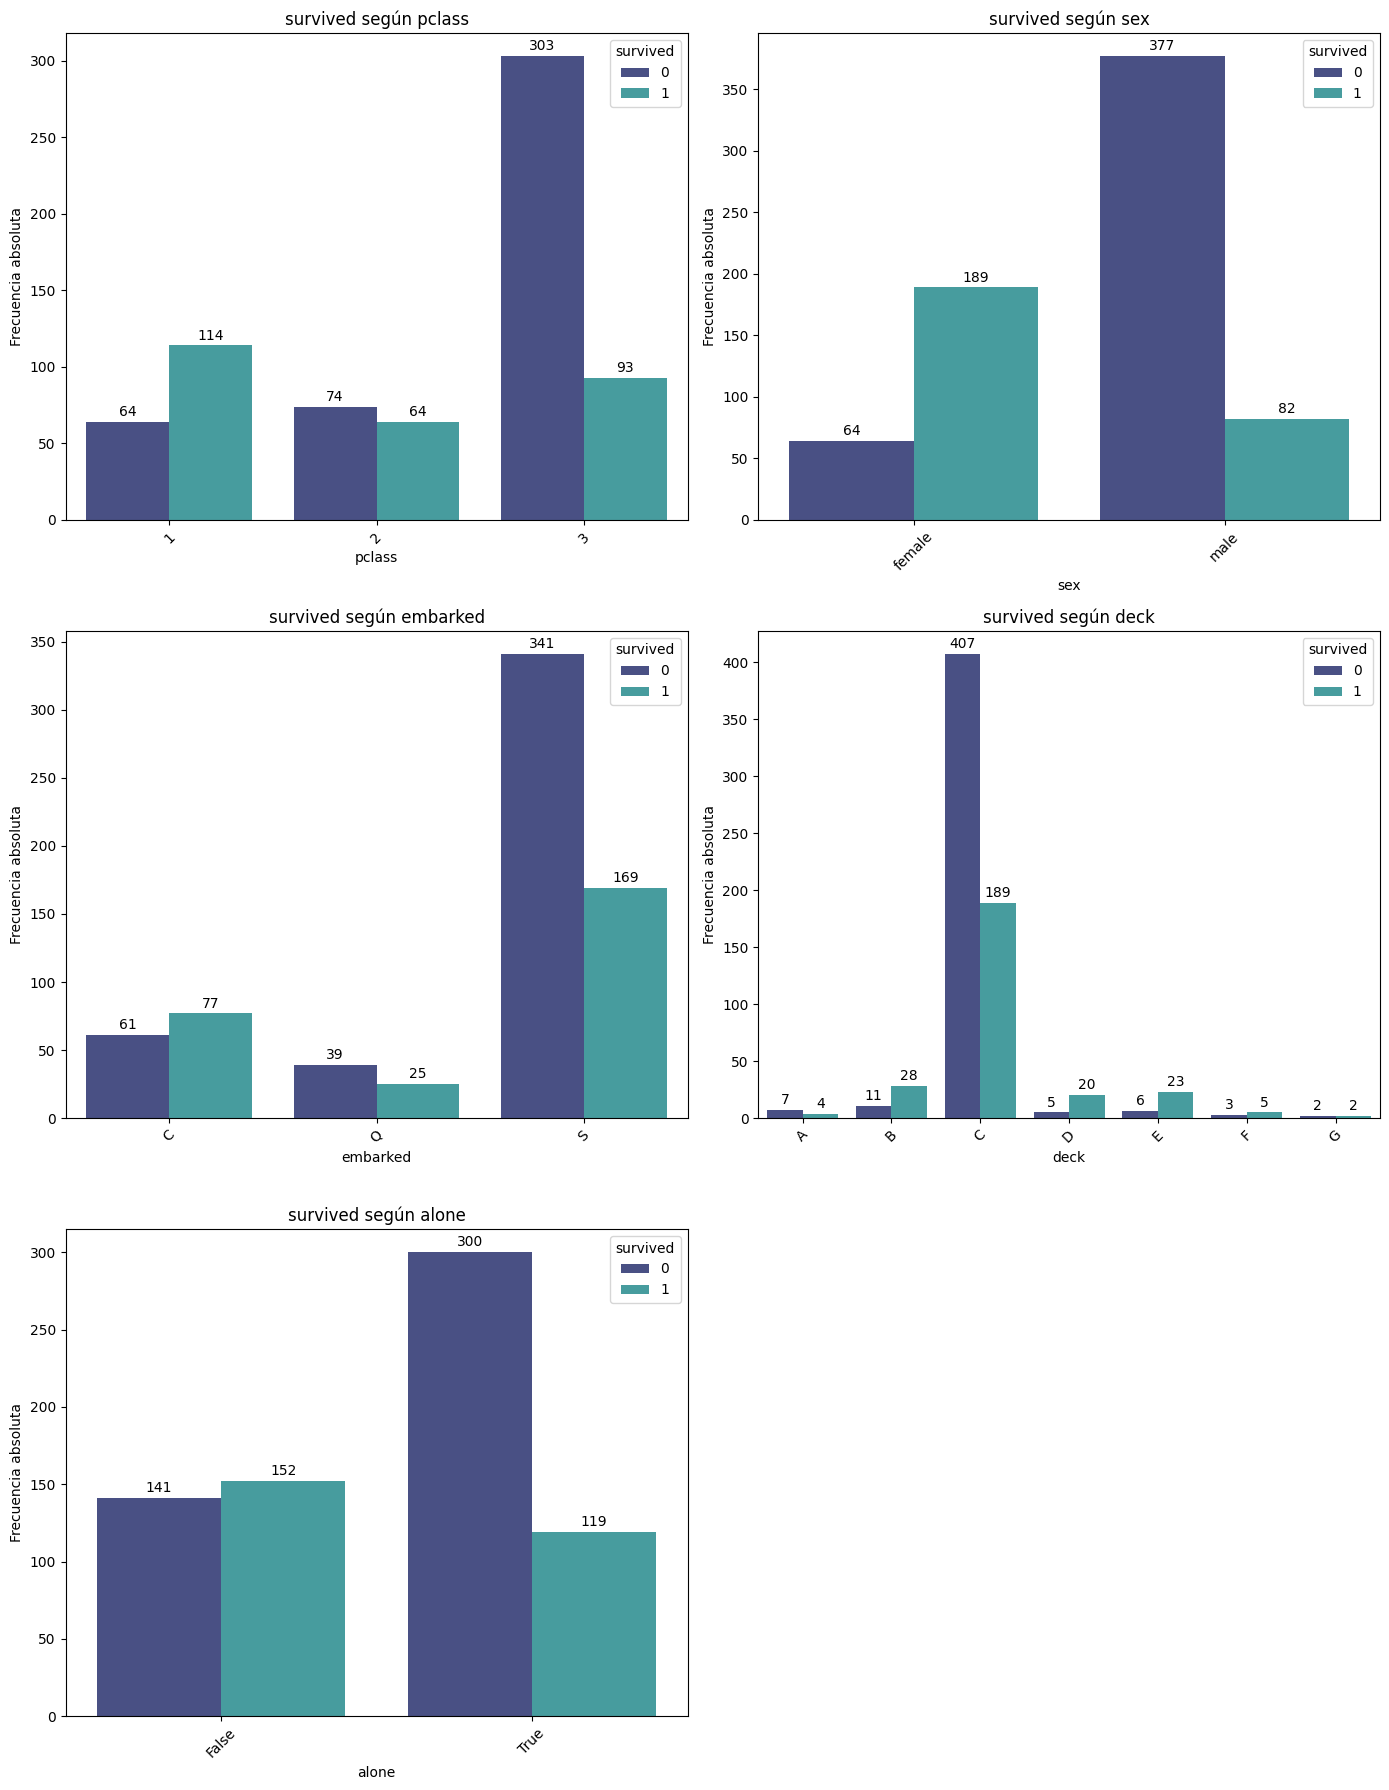

In [22]:
comparar_cualitativas(train_set, "survived", "pclass", "sex", "embarked", "deck", "alone")

In [23]:
from scipy.stats import chi2_contingency
vars_comparar = ["pclass", "sex", "embarked", "deck", "alone"]
for variable in vars_comparar:
    tabla_contingencia = pd.crosstab(train_set["survived"], train_set[variable])

    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"TEST CHI CUADRADO: survived - {variable}")
    print("Valor Chi-Cuadrado:", chi2)
    print("P-Value:", p)
    print("Grados de Libertad:", dof, end="\n"*2)

TEST CHI CUADRADO: survived - pclass
Valor Chi-Cuadrado: 90.7148254080481
P-Value: 2.002285255197973e-20
Grados de Libertad: 2

TEST CHI CUADRADO: survived - sex
Valor Chi-Cuadrado: 221.1032552967092
P-Value: 5.196825729783109e-50
Grados de Libertad: 1

TEST CHI CUADRADO: survived - embarked
Valor Chi-Cuadrado: 23.685815294083838
P-Value: 7.189365432775907e-06
Grados de Libertad: 2

TEST CHI CUADRADO: survived - deck
Valor Chi-Cuadrado: 70.8832545151131
P-Value: 2.6939484920652366e-13
Grados de Libertad: 6

TEST CHI CUADRADO: survived - alone
Valor Chi-Cuadrado: 39.31993998347713
P-Value: 3.5974870554902934e-10
Grados de Libertad: 1



Todas las variables cualitativas tienen una relación significativa con nuestro target, por lo que se espera que se muestre de la misma forma en la regresión.

## 8. Tratamiento de variables

In [24]:
for var in ["pclass", "sex", "embarked", "deck", "alone"]:
    print(var + ": ", X_train[var].unique())

pclass:  [3 1 2]
sex:  ['male' 'female']
embarked:  ['S' 'C' 'Q']
deck:  ['C', 'D', 'B', 'E', 'F', 'G', 'A']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
alone:  [ True False]


In [25]:
X_train["sex"] = (X_train.sex == "male").astype(int)
X_test["sex"] = (X_test.sex == "male").astype(int)

X_train["alone"] = X_train.alone.astype(int)
X_test["alone"] = X_test.alone.astype(int)

La variable deck es de typo 'category' de pandas, vamos a embarked a la misma para poder tratarlas juntas.

In [26]:
X_train.embarked = X_train.embarked.astype("category")
X_test.embarked = X_test.embarked.astype("category")

In [27]:
for var_multicat in ["embarked", "deck"]:
    categories = [X_train[var_multicat].unique().sort_values().tolist()]    # En orden de paradas del barco y orden alfabético de cubiertas
    enc = OrdinalEncoder(categories=categories)
    X_train[var_multicat] = enc.fit_transform(X_train[[var_multicat]])
    X_test[var_multicat] = enc.transform(X_test[[var_multicat]])

In [28]:
std_scaler = StandardScaler()

X_train["age"] = std_scaler.fit_transform(X_train[["age"]])
X_test["age"] = std_scaler.transform(X_test[["age"]])

## 9. Modelo de regresión logística

In [29]:
log_reg = LogisticRegression(max_iter = 5000)
log_reg.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [30]:
print(log_reg.coef_, log_reg.intercept_, log_reg.classes_, sep="\n")

[[-1.19729934 -2.66868745 -0.45819925 -0.37831761  0.35258935  0.00653139]]
[3.62543643]
[0 1]


### Importancia de las features

In [31]:
intercept = log_reg.intercept_
coefs = log_reg.coef_.ravel()

features = pd.DataFrame(coefs, X_train.columns, columns=['coefficient']).copy()
features['coefficient'] = np.abs(features['coefficient'])

features.sort_values('coefficient', ascending=False)

,coefficient
sex,2.668687
pclass,1.197299
age,0.458199
embarked,0.378318
deck,0.352589
alone,0.006531


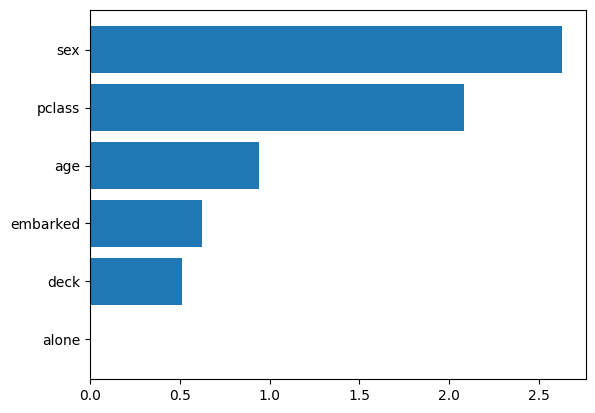

In [32]:
stdevs = []
for i in X_train.columns:
    stdev = X_train[i].std()
    stdevs.append(stdev)

features["stdev"] = np.array(stdevs).reshape(-1,1)
features["importance"] = features["coefficient"] * features["stdev"]
features['importance_standarized'] = features['importance'] / y_train.std()

features = features.sort_values('importance_standarized', ascending=True)
plt.barh(features.index, features.importance_standarized);

La variable alone no parece ser significativa, mientras que sex y class tienen un gran peso.

## 12. Evaluaciíon del modelo
(Nos saltamos el punto 11. Traramiento del test, porque ya lo hemos ido haciendo según tratábamos el train).

In [33]:
acc_train = round(accuracy_score(log_reg.predict(X_train), y_train), 3)
acc_test = round(accuracy_score(log_reg.predict(X_test), y_test), 3)

print("Accuracy train:", acc_train)
print("Accuracy test:", acc_test)

Accuracy train: 0.812
Accuracy test: 0.782


In [35]:
print("train: ", y_train.value_counts(True))
print()
print("test: ", y_test.value_counts(True))

train:  survived
0    0.619382
1    0.380618
Name: proportion, dtype: float64

test:  survived
0    0.603352
1    0.396648
Name: proportion, dtype: float64


El test falla bastante mas, indicando un posible overfitting. No aciertan mucho en general, habría que ver otras métricas.

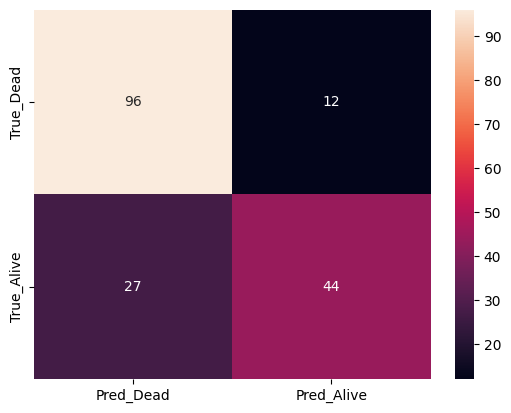

In [45]:
c_matrix = confusion_matrix(y_test, log_reg.predict(X_test))

c_matrix_df = pd.DataFrame(c_matrix, columns = ['Pred_Dead', 'Pred_Alive'],
                          index = ['True_Dead', 'True_Alive'])

sns.heatmap(c_matrix_df, annot=True, fmt='g');

Predice muchas muertes cuando es supervivencia.

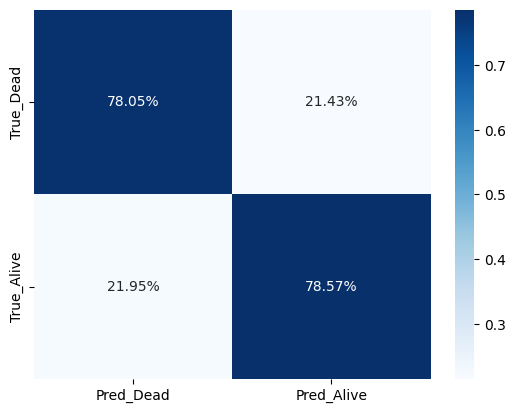

In [46]:
sns.heatmap(c_matrix_df/np.sum(c_matrix_df, axis=0), annot=True, 
            fmt='.2%', cmap='Blues');

### Clasification Report

In [47]:
print(classification_report(y_test, log_reg.predict(X_test)))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83       108
           1       0.79      0.62      0.69        71

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



Acierta más muertos que vivos, lo que era de esperar dada la diferencia de datos entre supervivientes y fallecidos. Clasifica bien un 78% de las muestras, acertando un 79% de las predicciones de resultado superviviente.

Sin embargo, de todos los supervivientes en la muestra, solo clasificó correctamente un 69%. Es decir, cuando cuando predice que el individuo sobrevive, lo hace con una probabilidad de acierto relativamente buena, aunque mejorable. Pero la clasificación es demasiado sensible, dando muchos falsos negativos. 

### Curva ROC
La curva refleja lo que ya hemos observado. Un área de 0.77 no está mal, pero podría mejorar, quizás eliminando las variables no significativas y probando con otras como fare.

AUROC: 0.77


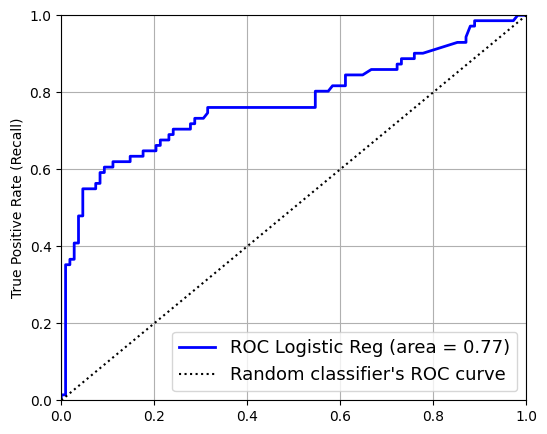

In [49]:
scores = log_reg.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, scores[:,1])
roc_auc = auc(fpr,tpr)
print("AUROC: %.2f" %(roc_auc))
plt.figure(figsize=(6, 5))  
plt.plot(fpr, tpr, linewidth=2, color= "blue", label=f"ROC Logistic Reg (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13);

El modelo no es muy bueno, siendo un 69% de positivos bien clasificados demasiado bajo para servir como modelo útil de predicción de la supervivencia.